In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('AVGO','PFE'), 
         ('AVGO','MO'), 
         ('AVGO','DOC'), 
         ('JPM','PFE'), 
         ('JPM', 'MO'),
         ('JPM', 'DOC'), 
         ('META','PFE'), 
         ('META', 'MO'), 
         ('META','DOC')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.1s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, 

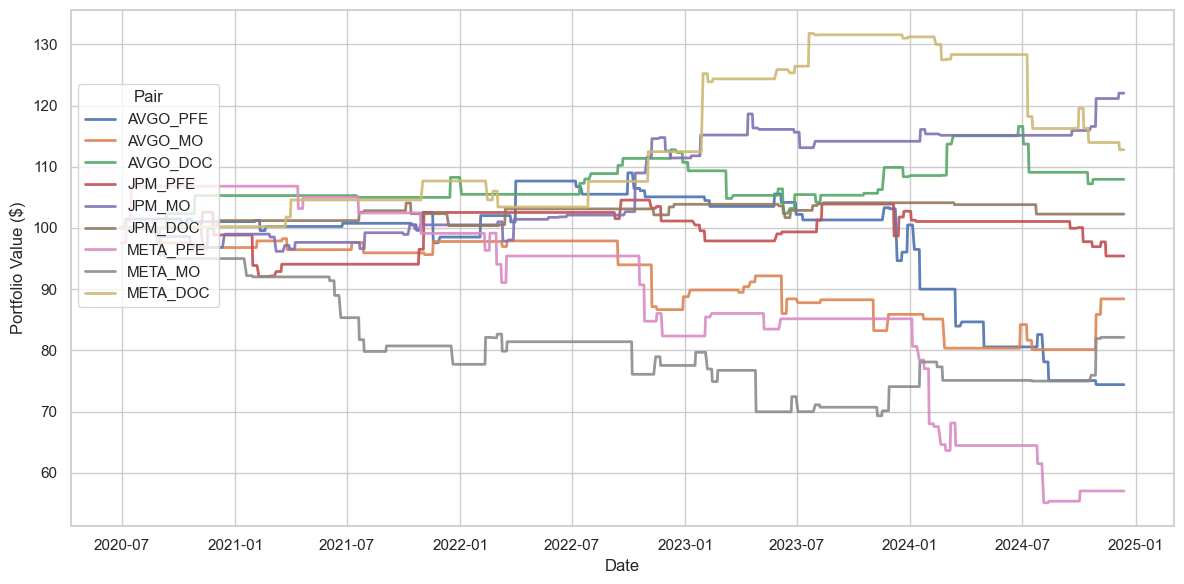

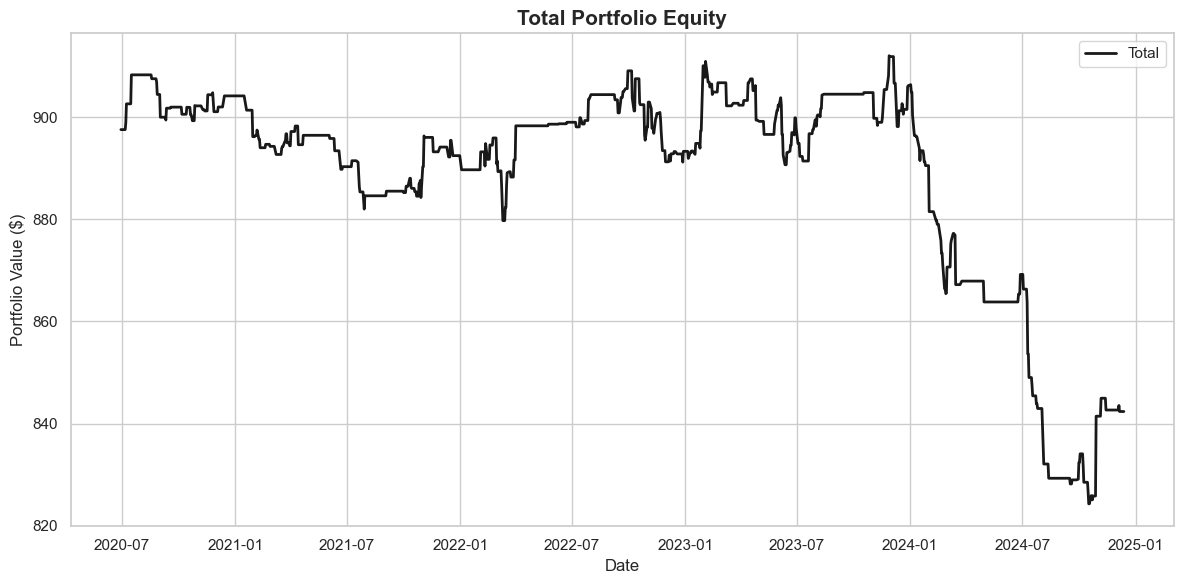

Summary
AVGO_PFE: Final Value = $74.40, Total Return = -25.60%, Trades = 42
AVGO_MO: Final Value = $88.41, Total Return = -11.59%, Trades = 34
AVGO_DOC: Final Value = $107.94, Total Return = 7.94%, Trades = 35
JPM_PFE: Final Value = $95.41, Total Return = -4.59%, Trades = 32
JPM_MO: Final Value = $122.02, Total Return = 22.02%, Trades = 46
JPM_DOC: Final Value = $102.26, Total Return = 2.26%, Trades = 22
META_PFE: Final Value = $57.03, Total Return = -41.54%, Trades = 33
META_MO: Final Value = $82.12, Total Return = -17.88%, Trades = 38
META_DOC: Final Value = $112.78, Total Return = 12.78%, Trades = 30

Total Portfolio Performance
Initial Portfolio Value: $897.55
Final Portfolio Value:   $842.36
Total Return:            -6.15%

Sharpe Ratios
AVGO_PFE: Sharpe Ratio = -0.64
AVGO_MO: Sharpe Ratio = -0.28
AVGO_DOC: Sharpe Ratio = 0.33
JPM_PFE: Sharpe Ratio = -0.13
JPM_MO: Sharpe Ratio = 0.79
JPM_DOC: Sharpe Ratio = 0.17
META_PFE: Sharpe Ratio = -0.91
META_MO: Sharpe Ratio = -0.38
META_DOC

In [5]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)